Dataset: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package?resource=download

# We are trying to predict if it will rain or not tomorrow

In [2]:
import pandas as pd

df = pd.read_csv('../weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
# the number of null (missing) values in each column
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [5]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


RainTomorrow     1.000000
Humidity3pm      0.439741
Cloud3pm         0.295054
Humidity9am      0.255292
Cloud9am         0.248829
Rainfall         0.235087
WindGustSpeed    0.224766
WindSpeed9am     0.090446
WindSpeed3pm     0.086973
MinTemp          0.083701
Temp9am         -0.025653
Evaporation     -0.090406
MaxTemp         -0.159060
Temp3pm         -0.190462
Pressure3pm     -0.214684
Pressure9am     -0.234022
Sunshine        -0.323714
Name: RainTomorrow, dtype: float64


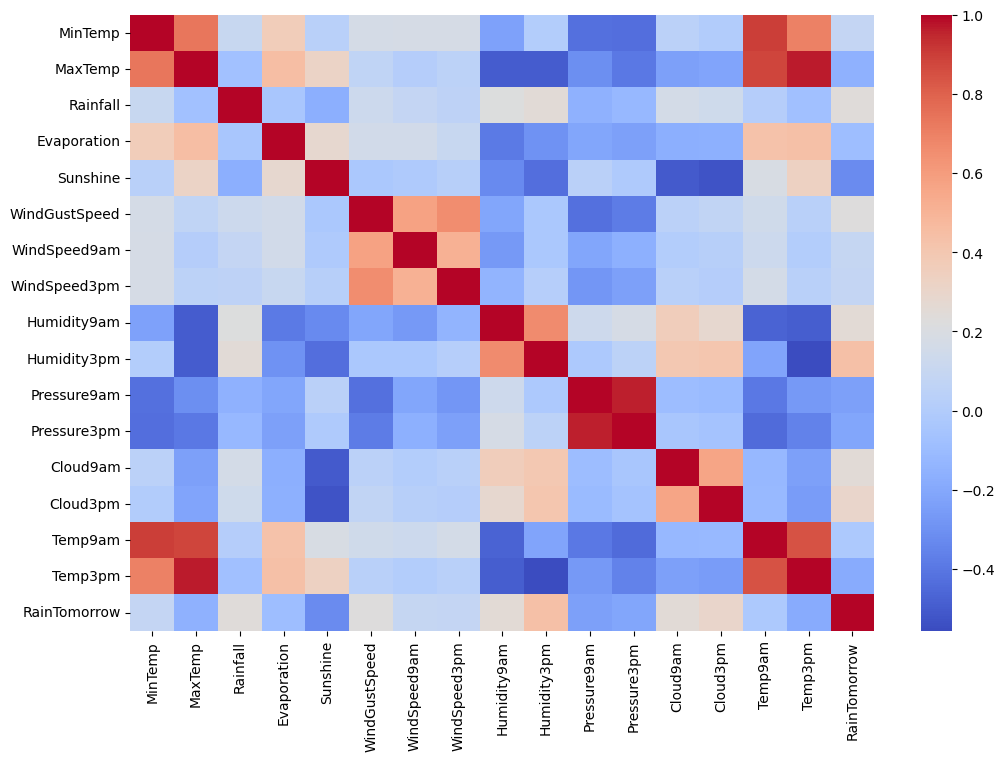

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean + convert target
df['RainTomorrow'] = df['RainTomorrow'].str.strip()
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Drop rows where target is missing
df = df.dropna(subset=['RainTomorrow'])

# Select numeric columns
num_df = df.select_dtypes(include=['float64', 'int64'])

# Fill missing values
num_df = num_df.fillna(num_df.median())

# Correlation with target
print(num_df.corr()['RainTomorrow'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='coolwarm')
plt.show()

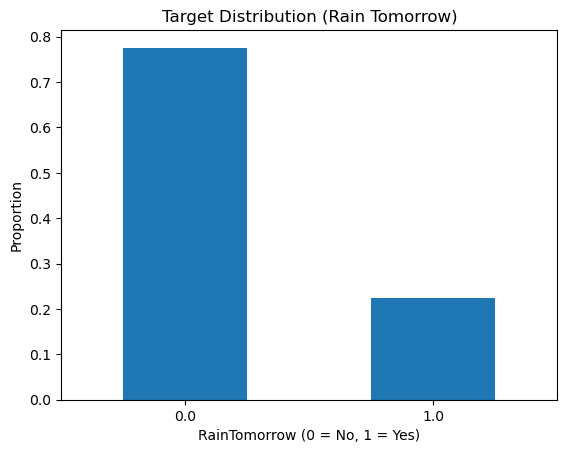

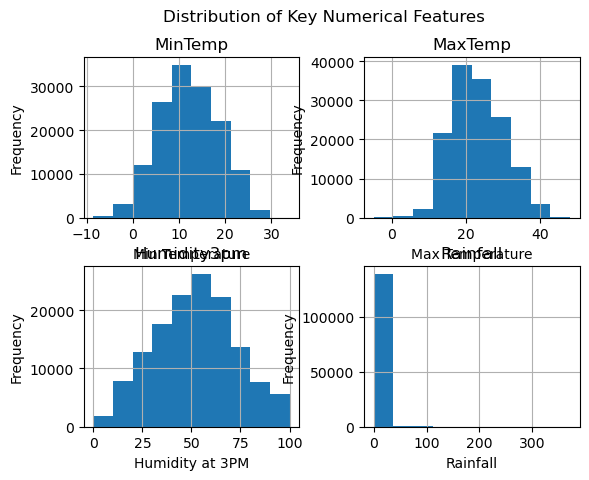

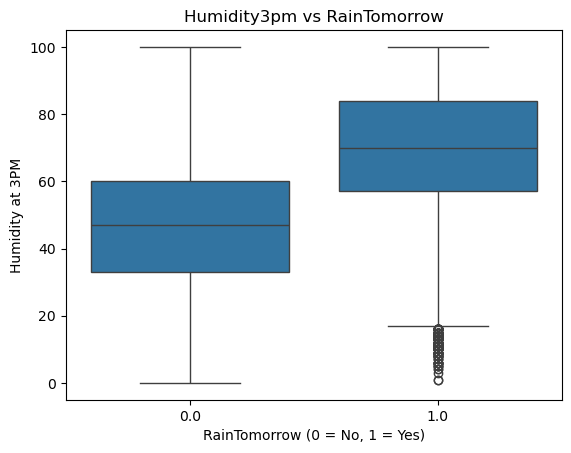

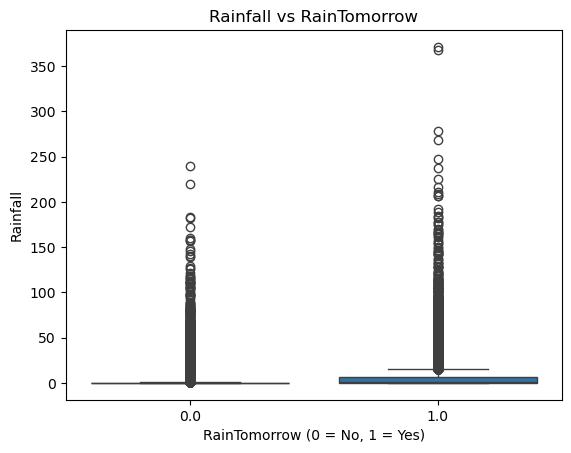

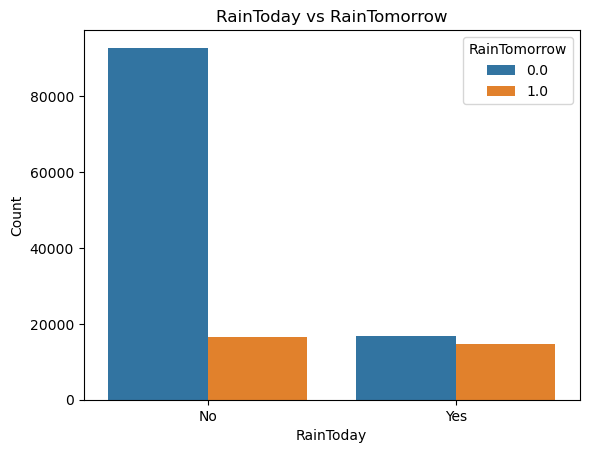

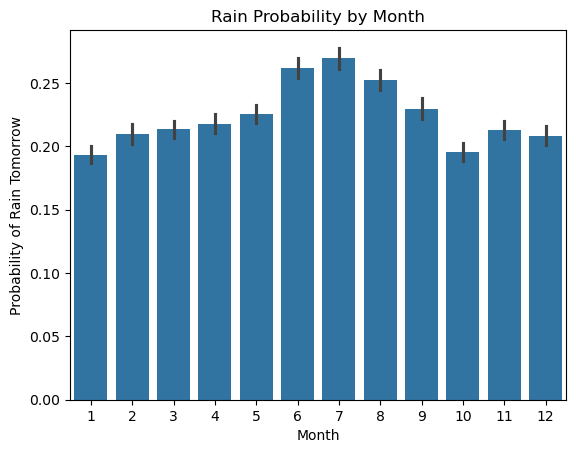

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# ======================
# Target Distribution
# ======================
plt.figure()
df['RainTomorrow'].value_counts(normalize=True).plot(kind='bar')
plt.title('Target Distribution (Rain Tomorrow)')
plt.xlabel('RainTomorrow (0 = No, 1 = Yes)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

# ======================
# Numerical Distribution (with labels)
# ======================
axes = df[['MinTemp','MaxTemp','Humidity3pm','Rainfall']].hist()

labels = ['Min Temperature', 'Max Temperature', 'Humidity at 3PM', 'Rainfall']

for ax, label in zip(axes.flatten(), labels):
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Key Numerical Features')
plt.show()

# ======================
# Feature vs Target
# ======================
plt.figure()
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title('Humidity3pm vs RainTomorrow')
plt.xlabel('RainTomorrow (0 = No, 1 = Yes)')
plt.ylabel('Humidity at 3PM')
plt.show()

plt.figure()
sns.boxplot(x='RainTomorrow', y='Rainfall', data=df)
plt.title('Rainfall vs RainTomorrow')
plt.xlabel('RainTomorrow (0 = No, 1 = Yes)')
plt.ylabel('Rainfall')
plt.show()

# ======================
# Categorical vs Target
# ======================
plt.figure()
sns.countplot(x='RainToday', hue='RainTomorrow', data=df)
plt.title('RainToday vs RainTomorrow')
plt.xlabel('RainToday')
plt.ylabel('Count')
plt.legend(title='RainTomorrow')
plt.show()

# ======================
# Time-based Analysis
# ======================
plt.figure()
sns.barplot(x='Month', y='RainTomorrow', data=df)
plt.title('Rain Probability by Month')
plt.xlabel('Month')
plt.ylabel('Probability of Rain Tomorrow')
plt.show()


In [8]:
num_df.corr()['RainTomorrow'].sort_values(ascending=False)

RainTomorrow     1.000000
Humidity3pm      0.439741
Cloud3pm         0.295054
Humidity9am      0.255292
Cloud9am         0.248829
Rainfall         0.235087
WindGustSpeed    0.224766
WindSpeed9am     0.090446
WindSpeed3pm     0.086973
MinTemp          0.083701
Temp9am         -0.025653
Evaporation     -0.090406
MaxTemp         -0.159060
Temp3pm         -0.190462
Pressure3pm     -0.214684
Pressure9am     -0.234022
Sunshine        -0.323714
Name: RainTomorrow, dtype: float64

## Finding from EDA. We found out that these are the most important features: Humidity3pm, Rainfall, Pressure3pm, Cloud3pm.

## Below contain test split with sample inpyt function to evaluate

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

features = ['Humidity3pm', 'Rainfall', 'Pressure3pm', 'Cloud3pm']
X = df[features]
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# Baseline logistic regression (no imbalance handling)
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Keep predictions around for comparison
y_pred_lr = model_lr.predict(X_test)

In [10]:
# humidity = float(input("Enter Humidity (0–100): "))
# rainfall = float(input("Enter Rainfall (0–300 mm): "))
# pressure = float(input("Enter Pressure (980–1040 hPa): "))
# cloud = float(input("Enter Cloud (0–9): "))

# sample = {
#     'Humidity3pm': humidity,
#     'Rainfall': rainfall,
#     'Pressure3pm': pressure,
#     'Cloud3pm': cloud
# }

# sample_df = pd.DataFrame([sample])
# sample_df = sample_df.reindex(columns=X_train.columns)

# prediction = model.predict(sample_df)[0]

# print("🌧️ Rain" if prediction == 1 else "☀️ No Rain")

Accuracy: 0.7596610288688069

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.77      0.83     22098
         1.0       0.47      0.73      0.58      6341

    accuracy                           0.76     28439
   macro avg       0.69      0.75      0.70     28439
weighted avg       0.81      0.76      0.78     28439



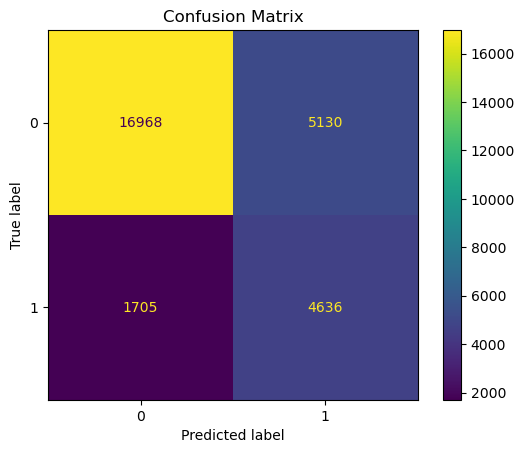


=== Testing with real samples ===
Actual: Rain 🌧️
Predicted: Rain 🌧️
------
Actual: No Rain ☀️
Predicted: No Rain ☀️
------
Actual: No Rain ☀️
Predicted: No Rain ☀️
------
Actual: Rain 🌧️
Predicted: Rain 🌧️
------
Actual: No Rain ☀️
Predicted: Rain 🌧️
------

=== Manual Prediction ===


In [ ]:
# =========================
# 1. IMPORT
# =========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# =========================
# 2. FEATURE SELECTION
# =========================
df = df.dropna(subset=['RainTomorrow'])

features = ['Humidity3pm', 'Rainfall', 'Pressure3pm', 'Cloud3pm']
X = df[features]
y = df['RainTomorrow']

# =========================
# 3. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. HANDLE MISSING VALUES
# =========================
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# =========================
# 5. TRAIN MODEL (Balanced Logistic Regression)
# =========================
model_bal = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_bal.fit(X_train, y_train)

# =========================
# 6. EVALUATION (Balanced Logistic)
# =========================
y_pred_bal = model_bal.predict(X_test)

print("Balanced Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal))

# =========================
# 6. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix (Balanced Logistic)")
plt.show()

# =========================
# 7. TEST WITH REAL DATA
# =========================
print("\n=== Testing with real samples ===")

for _ in range(5):
    row = df.sample(1)

    X_sample = row[features].fillna(X_train.median())
    y_true = row['RainTomorrow'].values[0]

    y_pred_sample = model_bal.predict(X_sample)[0]

    actual = "Rain 🌧️" if y_true == 1 else "No Rain ☀️"
    predicted = "Rain 🌧️" if y_pred_sample == 1 else "No Rain ☀️"

    print("Actual:", actual)
    print("Predicted:", predicted)
    print("------")

# =========================
# 8. USER INPUT LOOP
# =========================
print("\n=== Manual Prediction ===")

def get_input(prompt, min_val, max_val):
    while True:
        try:
            val = float(input(f"{prompt} ({min_val}–{max_val}): "))
            if min_val <= val <= max_val:
                return val
            else:
                print("Out of range, try again.")
        except:
            print("Invalid input.")

# while True:
#     humidity = get_input("Humidity3pm", 0, 100)
#     rainfall = get_input("Rainfall", 0, 300)
#     pressure = get_input("Pressure3pm", 980, 1040)
#     cloud = get_input("Cloud3pm", 0, 9)

#     sample = {
#         'Humidity3pm': humidity,
#         'Rainfall': rainfall,
#         'Pressure3pm': pressure,
#         'Cloud3pm': cloud
#     }

#     sample_df = pd.DataFrame([sample])
#     sample_df = sample_df.reindex(columns=X_train.columns)

#     prediction = model.predict(sample_df)[0]

#     print("\nPrediction:", "🌧️ Rain" if prediction == 1 else "☀️ No Rain")

#     cont = input("\nTry again? (y/n):")
#     if cont.lower() != 'y':
#         break

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, accuracy_score

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall (Rain):", recall_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7927142304581737
Recall (Rain): 0.4806812805551175
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87     22098
         1.0       0.54      0.48      0.51      6341

    accuracy                           0.79     28439
   macro avg       0.70      0.68      0.69     28439
weighted avg       0.79      0.79      0.79     28439



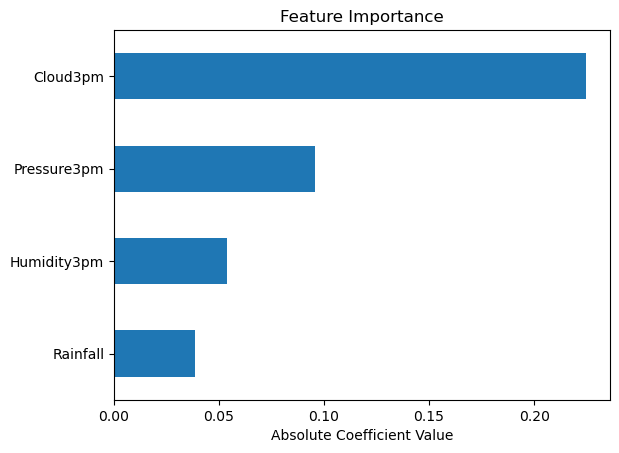

In [13]:
# visualized feature importance
# For LogisticRegression, use absolute coefficients as a proxy for feature importance
importance = pd.Series(abs(model.coef_[0]), index=X_train.columns)
importance.sort_values().plot(kind='barh')

plt.title('Feature Importance')
plt.xlabel('Absolute Coefficient Value')
plt.show()

# Model comparison: (These lines caused NameErrors as y_pred_lr, y_pred_lr_bal, y_pred_rf were not defined)
# If you want to compare models, ensure these prediction variables are calculated first.
# print("Logistic Recall:", recall_score(y_test, y_pred_lr))
# print("Balanced Logistic Recall:", recall_score(y_test, y_pred_lr_bal))
# print("Random Forest Recall:", recall_score(y_test, y_pred_rf))

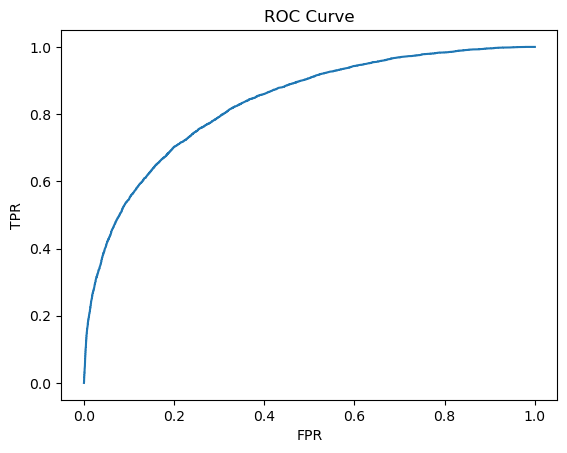

In [14]:
# ROC Curve
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, accuracy_score, classification_report

# Ensure we have a consistent split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fill missing numeric values using training set median
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# Train models
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr_bal = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

model_lr.fit(X_train, y_train)
model_lr_bal.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Predictions
y_pred_lr = model_lr.predict(X_test)
y_pred_bal = model_lr_bal.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

print("\n=== Model Comparison ===")
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Recall:", recall_score(y_test, y_pred_lr))
print()
print("Balanced LR Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Balanced LR Recall:", recall_score(y_test, y_pred_bal))
print()
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))

print("\n=== Balanced Logistic Classification Report ===")
print(classification_report(y_test, y_pred_bal))

print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))


=== Model Comparison ===
Logistic Accuracy: 0.8349098069552375
Logistic Recall: 0.44298039215686275

Balanced LR Accuracy: 0.7660958542846091
Balanced LR Recall: 0.7452549019607844

Random Forest Accuracy: 0.7995710116389465
Random Forest Recall: 0.4983529411764706

=== Balanced Logistic Classification Report ===
              precision    recall  f1-score   support

         0.0       0.91      0.77      0.84     22064
         1.0       0.49      0.75      0.59      6375

    accuracy                           0.77     28439
   macro avg       0.70      0.76      0.71     28439
weighted avg       0.82      0.77      0.78     28439


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

         0.0       0.86      0.89      0.87     22064
         1.0       0.56      0.50      0.53      6375

    accuracy                           0.80     28439
   macro avg       0.71      0.69      0.70     28439
weighted avg       0.79      0.80      0

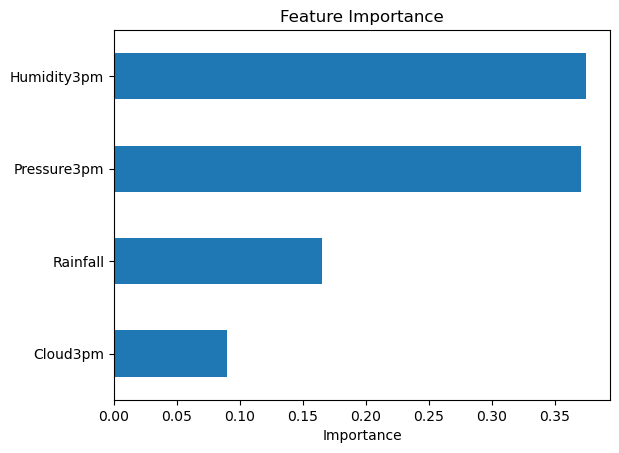

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model_rf.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh')

plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()